In [56]:
#05 archetype selection
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage,
)

from sklearn.cluster import (
    AgglomerativeClustering,
)

from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    pairwise_distances,
    silhouette_score,
)
# 1. File Paths
INPUT_FILE = Path(
    "/Users/cc-hoa/Desktop/毕业论文代码/results/"
    "Step_04_Final_Tier_Results.xlsx"
)

INPUT_SHEET = "Sheet1"

OUTPUT_DIR = Path(
    "/Users/cc-hoa/Desktop/毕业论文代码/results"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# 2. Read Dimension Scores and Tier Results
df = pd.read_excel(
    INPUT_FILE,
    sheet_name=INPUT_SHEET,
    engine="openpyxl",
)

DIMENSION_COLUMNS = [
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
]

X = df[DIMENSION_COLUMNS].to_numpy()
CANDIDATE_K = range(2, 7)

In [57]:
#Simple and Reproducible PAM-style K-medoids
#Additional algorithmic robustness checks
def fit_kmedoids(
    X,
    n_clusters,
    random_state=2026,
    n_init=100,
    max_iter=300,
):
    rng = np.random.default_rng(
        random_state
    )

    distances = pairwise_distances(
        X,
        metric="euclidean",
    )

    n_observations = X.shape[0]

    best_cost = np.inf
    best_labels = None
    best_medoids = None

    for _ in range(n_init):
        medoids = rng.choice(
            n_observations,
            size=n_clusters,
            replace=False,
        )

        for _ in range(max_iter):
            labels = np.argmin(
                distances[:, medoids],
                axis=1,
            )

            new_medoids = medoids.copy()

            for cluster in range(
                n_clusters
            ):
                members = np.where(
                    labels == cluster
                )[0]

                if len(members) == 0:
                    non_medoids = np.setdiff1d(
                        np.arange(n_observations),
                        new_medoids,
                    )

                    nearest_distance = np.min(
                        distances[
                            non_medoids
                        ][
                            :,
                            new_medoids,
                        ],
                        axis=1,
                    )

                    replacement = non_medoids[
                        np.argmax(
                            nearest_distance
                        )
                    ]

                    new_medoids[
                        cluster
                    ] = replacement

                    continue

                within_distances = distances[
                    np.ix_(
                        members,
                        members,
                    )
                ]

                member_costs = (
                    within_distances.sum(
                        axis=1
                    )
                )

                new_medoids[
                    cluster
                ] = members[
                    np.argmin(
                        member_costs
                    )
                ]

            if np.array_equal(
                np.sort(new_medoids),
                np.sort(medoids),
            ):
                medoids = new_medoids
                break

            medoids = new_medoids

        labels = np.argmin(
            distances[:, medoids],
            axis=1,
        )

        cost = np.sum(
            distances[
                np.arange(n_observations),
                medoids[labels],
            ]
        )

        if cost < best_cost:
            best_cost = cost
            best_labels = labels.copy()
            best_medoids = medoids.copy()

    return (
        best_labels,
        best_medoids,
        best_cost,
    )


In [58]:
#Calculate the proportion of UHI variance explained by the archetype
def eta_squared(values, labels):
    values = np.asarray(values)
    labels = np.asarray(labels)

    grand_mean = values.mean()

    total_sum_squares = np.sum(
        (values - grand_mean) ** 2
    )

    between_sum_squares = 0.0

    for label in np.unique(labels):
        group_values = values[
            labels == label
        ]

        between_sum_squares += (
            len(group_values)
            * (
                group_values.mean()
                - grand_mean
            ) ** 2
        )

    return (
        between_sum_squares
        / total_sum_squares
    )

In [59]:
#prework for archetype
#Run candidate Ward and K-medoids algorithms
diagnostic_rows = []
candidate_assignments = df[
    [
        "FUA_Code",
        "FUA_Name",
        "ISO3",
        "UHI",
        "UHI_rank",
        "Tier_KMeans",
        *DIMENSION_COLUMNS,
    ]
].copy()

profile_rows = []
medoid_rows = []

for k in CANDIDATE_K:
# Ward 
    ward = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    ward_labels = ward.fit_predict(X)
    ward_clusters = ward_labels + 1

    candidate_assignments[
        f"Ward_Archetype_k{k}"
    ] = ward_clusters

# K-medoids 
    (
        medoid_labels,
        medoid_indices,
        medoid_cost,
    ) = fit_kmedoids(
        X=X,
        n_clusters=k,
        random_state=2026,
        n_init=100,
    )

    medoid_clusters = medoid_labels + 1

    candidate_assignments[
        f"KMedoids_Archetype_k{k}"
    ] = medoid_clusters

# diagnosis 
    silhouette = silhouette_score(
        X,
        ward_labels,
    )

    calinski_harabasz = (
        calinski_harabasz_score(
            X,
            ward_labels,
        )
    )

    davies_bouldin = (
        davies_bouldin_score(
            X,
            ward_labels,
        )
    )

    ward_kmedoids_ari = (
        adjusted_rand_score(
            ward_labels,
            medoid_labels,
        )
    )

    tier_ari = adjusted_rand_score(
        df["Tier_KMeans"],
        ward_labels,
    )

    tier_nmi = normalized_mutual_info_score(
        df["Tier_KMeans"],
        ward_labels,
    )

    uhi_eta_squared = eta_squared(
        df["UHI"],
        ward_labels,
    )

    cluster_sizes = (
        pd.Series(ward_clusters)
        .value_counts()
        .sort_index()
    )

    diagnostic_rows.append({
        "K": k,
        "Ward_Silhouette": silhouette,
        "Ward_Calinski_Harabasz":
            calinski_harabasz,
        "Ward_Davies_Bouldin":
            davies_bouldin,
        "Ward_KMedoids_ARI":
            ward_kmedoids_ari,
        "Archetype_Tier_ARI":
            tier_ari,
        "Archetype_Tier_NMI":
            tier_nmi,
        "UHI_Eta_Squared":
            uhi_eta_squared,
        "Minimum_Cluster_Size":
            cluster_sizes.min(),
        "Maximum_Cluster_Size":
            cluster_sizes.max(),
        "Cluster_Sizes": "; ".join(
            f"C{cluster}={size}"
            for cluster, size
            in cluster_sizes.items()
        ),
        "KMedoids_Total_Cost":
            medoid_cost,
    })

# Ward Type Profiling
    temporary = df.copy()
    temporary["Cluster"] = ward_clusters

    cluster_profiles = (
        temporary.groupby("Cluster")
        .agg(
            Number_of_Cities=(
                "FUA_Code",
                "count",
            ),
            Mean_UHI=(
                "UHI",
                "mean",
            ),
            SD_UHI=(
                "UHI",
                "std",
            ),
            Mean_DEM=(
                "DEM_star",
                "mean",
            ),
            Mean_ECO=(
                "ECO_star",
                "mean",
            ),
            Mean_TRA=(
                "TRA_star",
                "mean",
            ),
            Mean_FUN=(
                "FUN_star",
                "mean",
            ),
        )
        .reset_index()
    )

    cluster_profiles.insert(
        0,
        "K",
        k,
    )

    profile_rows.append(
        cluster_profiles
    )

# K-medoids Representative cities
    for cluster_number, medoid_index in enumerate(
        medoid_indices,
        start=1,
    ):
        medoid_rows.append({
            "K": k,
            "KMedoids_Cluster":
                cluster_number,
            "FUA_Code":
                df.iloc[medoid_index][
                    "FUA_Code"
                ],
            "FUA_Name":
                df.iloc[medoid_index][
                    "FUA_Name"
                ],
            "ISO3":
                df.iloc[medoid_index][
                    "ISO3"
                ],
            "UHI":
                df.iloc[medoid_index][
                    "UHI"
                ],
            "DEM_star":
                df.iloc[medoid_index][
                    "DEM_star"
                ],
            "ECO_star":
                df.iloc[medoid_index][
                    "ECO_star"
                ],
            "TRA_star":
                df.iloc[medoid_index][
                    "TRA_star"
                ],
            "FUN_star":
                df.iloc[medoid_index][
                    "FUN_star"
                ],
        })
diagnostics = pd.DataFrame(
    diagnostic_rows
)
cluster_profiles = pd.concat(
    profile_rows,
    ignore_index=True,
)
medoid_cities = pd.DataFrame(
    medoid_rows
)

In [60]:
#Display Results
print("Diagnostic Metrics")
display(diagnostics.round(3))
print("Ward Cluster Profiles")
display(cluster_profiles.round(3))
print("K-medoid Representative Cities")
display(medoid_cities)

#Save Results
diagnostics.to_excel(
    OUTPUT_DIR / "Step_05_Diagnostic_Metrics.xlsx",
    index=False,
)

cluster_profiles.to_excel(
    OUTPUT_DIR / "Step_05_Cluster_Profiles.xlsx",
    index=False,
)

medoid_cities.to_excel(
    OUTPUT_DIR / "Step_05_KMedoids.xlsx",
    index=False,
)

candidate_assignments.to_excel(
    OUTPUT_DIR / "Step_05_Candidate_Clusters.xlsx",
    index=False,
)

Diagnostic Metrics


,K,Ward_Silhouette,Ward_Calinski_Harabasz,Ward_Davies_Bouldin,Ward_KMedoids_ARI,Archetype_Tier_ARI,Archetype_Tier_NMI,UHI_Eta_Squared,Minimum_Cluster_Size,Maximum_Cluster_Size,Cluster_Sizes,KMedoids_Total_Cost
0,2,0.511,69.915,0.688,0.719,0.270,0.494,0.707,13,43,C1=43; C2=13,71.080
1,3,0.366,65.873,0.958,0.775,0.610,0.713,0.888,13,25,C1=25; C2=13; C3=18,58.742
2,4,0.327,57.074,0.980,0.781,0.596,0.669,0.904,12,18,C1=13; C2=12; C3=18; C4=13,52.169
3,5,0.312,52.651,1.018,0.653,0.541,0.643,0.913,3,18,C1=18; C2=12; C3=10; C4=13; C5=3,48.317
4,6,0.256,48.645,1.087,0.738,0.483,0.637,0.927,3,13,C1=10; C2=12; C3=11; C4=13; C5=3; C6=7,44.544


Ward Cluster Profiles


,K,Cluster,Number_of_Cities,Mean_UHI,SD_UHI,Mean_DEM,Mean_ECO,Mean_TRA,Mean_FUN
0,2,1,43,-0.408,0.506,-0.452,-0.374,-0.388,-0.418
1,2,2,13,1.350,0.415,1.495,1.239,1.284,1.384
2,3,1,25,-0.044,0.278,-0.117,-0.090,0.084,-0.055
3,3,2,13,1.350,0.415,1.495,1.239,1.284,1.384
4,3,3,18,-0.914,0.241,-0.918,-0.770,-1.044,-0.923
5,4,1,13,1.350,0.415,1.495,1.239,1.284,1.384
6,4,2,12,0.131,0.225,-0.011,0.593,-0.088,0.029
7,4,3,18,-0.914,0.241,-0.918,-0.770,-1.044,-0.923
8,4,4,13,-0.206,0.223,-0.214,-0.720,0.243,-0.132
9,5,1,18,-0.914,0.241,-0.918,-0.770,-1.044,-0.923


K-medoid Representative Cities


,K,KMedoids_Cluster,FUA_Code,FUA_Name,ISO3,UHI,DEM_star,ECO_star,TRA_star,FUN_star
0,2,1,USA03F,Chicago,USA,1.073055,1.192065,1.164011,1.094090,0.842054
1,2,2,FR006F,Toulouse,FRA,-0.478505,-0.737919,-0.307084,-0.614820,-0.254196
2,3,1,USA03F,Chicago,USA,1.073055,1.192065,1.164011,1.094090,0.842054
3,3,2,FR002F,Lyon,FRA,-0.016234,-0.300124,0.257576,-0.104468,0.082079
4,3,3,FR007F,Nantes,FRA,-0.786065,-1.116095,-0.620468,-0.637803,-0.769894
5,4,1,USA03F,Chicago,USA,1.073055,1.192065,1.164011,1.094090,0.842054
6,4,2,UK013F,Newcastle upon Tyne,GBR,-1.097631,-0.980328,-1.280123,-1.066941,-1.063131
7,4,3,JPN06F,Sendai,JPN,-0.402295,-0.674998,-1.115797,0.344289,-0.162674
8,4,4,DE004F,Köln,DEU,-0.063303,-0.258727,0.347575,-0.066719,-0.275339
9,5,1,FR007F,Nantes,FRA,-0.786065,-1.116095,-0.620468,-0.637803,-0.769894


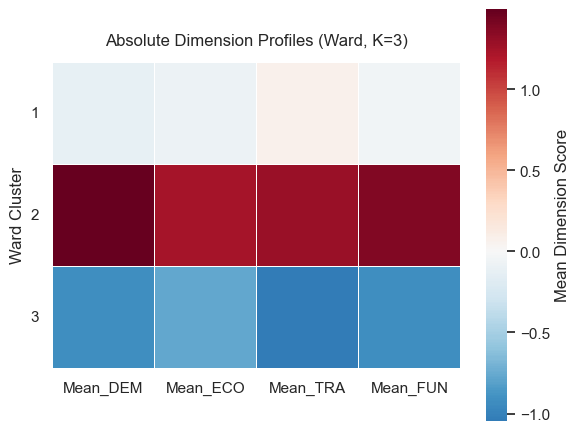

In [61]:
# Heatmap of Absolute Cluster Profiles
import matplotlib.pyplot as plt
import seaborn as sns
# Select candidate k
SELECTED_K = 3
#
heatmap_data = (
    cluster_profiles
    .query("K == @SELECTED_K")
    .set_index("Cluster")[
        [
            "Mean_DEM",
            "Mean_ECO",
            "Mean_TRA",
            "Mean_FUN",
        ]
    ]
)
plt.figure(figsize=(6, 4.5))

sns.heatmap(
    heatmap_data,
    annot=False,    
    cmap="RdBu_r",
    center=0,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Mean Dimension Score"
    },
)

plt.xlabel("")
plt.ylabel("Ward Cluster")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title(
    f"Absolute Dimension Profiles (Ward, K={SELECTED_K})",
    pad=12,
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"Step_05_Ward_Profiles_K{SELECTED_K}.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

In [62]:
#Read Data
df = pd.read_excel(
    INPUT_FILE,
    sheet_name=INPUT_SHEET,
    engine="openpyxl",
)

DIMENSION_COLUMNS = [
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
]

X = df[DIMENSION_COLUMNS].to_numpy()
CANDIDATE_K = range(2, 7)

In [63]:
#Construct Relative Dimension Profiles
df["DEM_profile"] = (
    df["DEM_star"] - df["UHI"]
)

df["ECO_profile"] = (
    df["ECO_star"] - df["UHI"]
)

df["TRA_profile"] = (
    df["TRA_star"] - df["UHI"]
)

df["FUN_profile"] = (
    df["FUN_star"] - df["UHI"]
)

PROFILE_COLUMNS = [
    "DEM_profile",
    "ECO_profile",
    "TRA_profile",
    "FUN_profile",
]
# Optional consistency check
assert np.allclose(
    df[PROFILE_COLUMNS].sum(axis=1),
    0,
)

X = df[PROFILE_COLUMNS].to_numpy()

CANDIDATE_K = range(2, 7)

In [64]:
#Proportion of UHI variance explained
def eta_squared(values, labels):
    values = np.asarray(values)
    labels = np.asarray(labels)

    grand_mean = values.mean()

    total_ss = np.sum(
        (values - grand_mean) ** 2
    )

    between_ss = 0.0

    for label in np.unique(labels):
        group = values[
            labels == label
        ]

        between_ss += (
            len(group)
            * (
                group.mean()
                - grand_mean
            ) ** 2
        )

    return between_ss / total_ss

In [65]:
#Perform candidate Ward clustering on relative profiles
diagnostic_rows = []
profile_rows = []
candidate_assignments = df[
    [
        "FUA_Code",
        "FUA_Name",
        "ISO3",
        "UHI",
        "UHI_rank",
        "Tier_KMeans",
        *DIMENSION_COLUMNS,
        *PROFILE_COLUMNS,
    ]
].copy()


for k in CANDIDATE_K:
    ward = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = ward.fit_predict(X)
    clusters = labels + 1

    candidate_assignments[
        f"Profile_Ward_k{k}"
    ] = clusters

    silhouette = silhouette_score(
        X,
        labels,
    )

    calinski_harabasz = (
        calinski_harabasz_score(
            X,
            labels,
        )
    )

    davies_bouldin = (
        davies_bouldin_score(
            X,
            labels,
        )
    )

    tier_ari = adjusted_rand_score(
        df["Tier_KMeans"],
        labels,
    )

    tier_nmi = normalized_mutual_info_score(
        df["Tier_KMeans"],
        labels,
    )

    uhi_eta = eta_squared(
        df["UHI"],
        labels,
    )

    cluster_sizes = (
        pd.Series(clusters)
        .value_counts()
        .sort_index()
    )

    diagnostic_rows.append({
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz":
            calinski_harabasz,
        "Davies_Bouldin":
            davies_bouldin,
        "Archetype_Tier_ARI":
            tier_ari,
        "Archetype_Tier_NMI":
            tier_nmi,
        "UHI_Eta_Squared":
            uhi_eta,
        "Minimum_Cluster_Size":
            cluster_sizes.min(),
        "Maximum_Cluster_Size":
            cluster_sizes.max(),
        "Cluster_Sizes": "; ".join(
            f"C{cluster}={size}"
            for cluster, size
            in cluster_sizes.items()
        ),
    })

    temporary = df.copy()
    temporary["Cluster"] = clusters

    profiles = (
        temporary.groupby("Cluster")
        .agg(
            Number_of_Cities=(
                "FUA_Code",
                "count",
            ),
            Mean_UHI=(
                "UHI",
                "mean",
            ),
            SD_UHI=(
                "UHI",
                "std",
            ),
            Mean_DEM_Profile=(
                "DEM_profile",
                "mean",
            ),
            Mean_ECO_Profile=(
                "ECO_profile",
                "mean",
            ),
            Mean_TRA_Profile=(
                "TRA_profile",
                "mean",
            ),
            Mean_FUN_Profile=(
                "FUN_profile",
                "mean",
            ),
            Mean_Original_DEM=(
                "DEM_star",
                "mean",
            ),
            Mean_Original_ECO=(
                "ECO_star",
                "mean",
            ),
            Mean_Original_TRA=(
                "TRA_star",
                "mean",
            ),
            Mean_Original_FUN=(
                "FUN_star",
                "mean",
            ),
        )
        .reset_index()
    )

    profiles.insert(
        0,
        "K",
        k,
    )

    profile_rows.append(profiles)


diagnostics = pd.DataFrame(
    diagnostic_rows
)

cluster_profiles = pd.concat(
    profile_rows,
    ignore_index=True,
)

In [66]:
#Display Results
print("Diagnostic Metrics")
display(diagnostics.round(3))

print("Candidate Archetype Profiles")
display(
    cluster_profiles[
        [
            "K",
            "Cluster",
            "Number_of_Cities",
            "Mean_UHI",
            "Mean_DEM_Profile",
            "Mean_ECO_Profile",
            "Mean_TRA_Profile",
            "Mean_FUN_Profile",
        ]
    ].round(3)
)

#Save Results
diagnostics.to_excel(
    OUTPUT_DIR / "Step_06_Diagnostic_Metrics.xlsx",
    index=False,
)

cluster_profiles.to_excel(
    OUTPUT_DIR / "Step_06_Cluster_Profiles.xlsx",
    index=False,
)

candidate_assignments.to_excel(
    OUTPUT_DIR / "Step_06_Candidate_Archetypes.xlsx",
    index=False,
)

Diagnostic Metrics


,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Archetype_Tier_ARI,Archetype_Tier_NMI,UHI_Eta_Squared,Minimum_Cluster_Size,Maximum_Cluster_Size,Cluster_Sizes
0,2,0.287,31.813,1.146,-0.001,0.034,0.001,20,36,C1=36; C2=20
1,3,0.251,30.184,1.189,0.002,0.073,0.040,9,27,C1=27; C2=20; C3=9
2,4,0.229,27.109,1.223,-0.002,0.074,0.047,7,20,C1=20; C2=20; C3=9; C4=7
3,5,0.258,27.854,1.094,-0.009,0.090,0.048,6,20,C1=20; C2=14; C3=9; C4=7; C5=6
4,6,0.242,26.727,1.018,-0.006,0.097,0.048,6,14,C1=14; C2=12; C3=9; C4=7; C5=6; C6=8


Candidate Archetype Profiles


,K,Cluster,Number_of_Cities,Mean_UHI,Mean_DEM_Profile,Mean_ECO_Profile,Mean_TRA_Profile,Mean_FUN_Profile
0,2,1,36,0.020,0.001,-0.333,0.148,0.184
1,2,2,20,-0.036,-0.002,0.599,-0.267,-0.330
2,3,1,27,-0.105,0.033,-0.150,-0.031,0.148
3,3,2,20,-0.036,-0.002,0.599,-0.267,-0.330
4,3,3,9,0.395,-0.094,-0.881,0.686,0.289
5,4,1,20,-0.036,-0.002,0.599,-0.267,-0.330
6,4,2,20,-0.043,-0.046,0.004,0.011,0.031
7,4,3,9,0.395,-0.094,-0.881,0.686,0.289
8,4,4,7,-0.285,0.258,-0.590,-0.152,0.484
9,5,1,20,-0.043,-0.046,0.004,0.011,0.031


In [67]:
# ============================================================
# 8. Compare K = 4 and K = 5
# ============================================================

COMPARE_K = [4, 5]

# ------------------------------------------------------------
# 8.1 Compare diagnostic metrics
# ------------------------------------------------------------

k_comparison = diagnostics[
    diagnostics["K"].isin(COMPARE_K)
][
    [
        "K",
        "Silhouette",
        "Calinski_Harabasz",
        "Davies_Bouldin",
        "Archetype_Tier_ARI",
        "Archetype_Tier_NMI",
        "UHI_Eta_Squared",
        "Minimum_Cluster_Size",
        "Maximum_Cluster_Size",
        "Cluster_Sizes",
    ]
].copy()

print("K = 4 vs K = 5: Diagnostic Comparison")
display(k_comparison.round(3))


# ------------------------------------------------------------
# 8.2 Compare relative profile centres
# ------------------------------------------------------------

profile_comparison = cluster_profiles[
    cluster_profiles["K"].isin(COMPARE_K)
][
    [
        "K",
        "Cluster",
        "Number_of_Cities",
        "Mean_UHI",
        "Mean_DEM_Profile",
        "Mean_ECO_Profile",
        "Mean_TRA_Profile",
        "Mean_FUN_Profile",
    ]
].copy()

print("K = 4 vs K = 5: Relative Profile Comparison")
display(profile_comparison.round(3))


# ------------------------------------------------------------
# 8.3 Save comparison tables
# ------------------------------------------------------------

k_comparison.to_excel(
    OUTPUT_DIR / "Step_06_K4_K5_Diagnostic_Comparison.xlsx",
    index=False,
)

profile_comparison.to_excel(
    OUTPUT_DIR / "Step_06_K4_K5_Profile_Comparison.xlsx",
    index=False,
)

K = 4 vs K = 5: Diagnostic Comparison


,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Archetype_Tier_ARI,Archetype_Tier_NMI,UHI_Eta_Squared,Minimum_Cluster_Size,Maximum_Cluster_Size,Cluster_Sizes
2,4,0.229,27.109,1.223,-0.002,0.074,0.047,7,20,C1=20; C2=20; C3=9; C4=7
3,5,0.258,27.854,1.094,-0.009,0.090,0.048,6,20,C1=20; C2=14; C3=9; C4=7; C5=6


K = 4 vs K = 5: Relative Profile Comparison


,K,Cluster,Number_of_Cities,Mean_UHI,Mean_DEM_Profile,Mean_ECO_Profile,Mean_TRA_Profile,Mean_FUN_Profile
5,4,1,20,-0.036,-0.002,0.599,-0.267,-0.330
6,4,2,20,-0.043,-0.046,0.004,0.011,0.031
7,4,3,9,0.395,-0.094,-0.881,0.686,0.289
8,4,4,7,-0.285,0.258,-0.590,-0.152,0.484
9,5,1,20,-0.043,-0.046,0.004,0.011,0.031
10,5,2,14,-0.001,-0.143,0.623,-0.056,-0.424
11,5,3,9,0.395,-0.094,-0.881,0.686,0.289
12,5,4,7,-0.285,0.258,-0.590,-0.152,0.484
13,5,5,6,-0.115,0.327,0.544,-0.759,-0.111


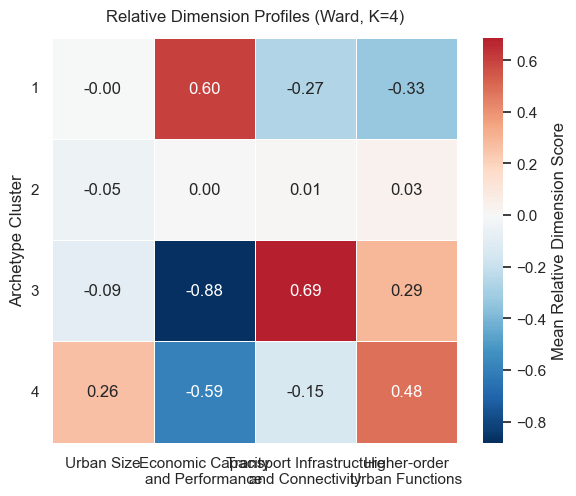

In [68]:
#Heatmap for K = 4
heatmap_k4 = (
    cluster_profiles
    .query("K == 4")
    .set_index("Cluster")[
        [
            "Mean_DEM_Profile",
            "Mean_ECO_Profile",
            "Mean_TRA_Profile",
            "Mean_FUN_Profile",
        ]
    ]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    heatmap_k4,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Mean Relative Dimension Score"
    },
)

plt.xlabel("")
plt.ylabel("Archetype Cluster")
plt.xticks(
    ticks=[0.5, 1.5, 2.5, 3.5],
    labels=[
        "Urban Size",
        "Economic Capacity\nand Performance",
        "Transport Infrastructure\nand Connectivity",
        "Higher-order\nUrban Functions",
    ],
    rotation=0,
)

plt.yticks(rotation=0)

plt.title(
    "Relative Dimension Profiles (Ward, K=4)",
    pad=12,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Step_06_Relative_Profiles_K4.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

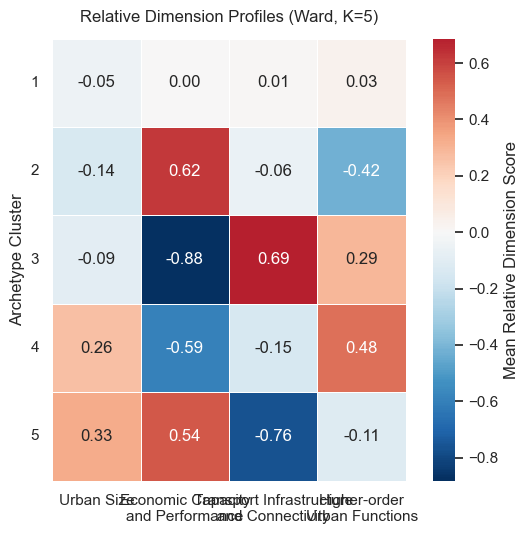

In [69]:
# Heatmap for K = 5
heatmap_k5 = (
    cluster_profiles
    .query("K == 5")
    .set_index("Cluster")[
        [
            "Mean_DEM_Profile",
            "Mean_ECO_Profile",
            "Mean_TRA_Profile",
            "Mean_FUN_Profile",
        ]
    ]
)

plt.figure(figsize=(6, 5.5))

sns.heatmap(
    heatmap_k5,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Mean Relative Dimension Score"
    },
)

plt.xlabel("")
plt.ylabel("Archetype Cluster")
plt.xticks(
    ticks=[0.5, 1.5, 2.5, 3.5],
    labels=[
        "Urban Size",
        "Economic Capacity\nand Performance",
        "Transport Infrastructure\nand Connectivity",
        "Higher-order\nUrban Functions",
    ],
    rotation=0,
)

plt.yticks(rotation=0)

plt.title(
    "Relative Dimension Profiles (Ward, K=5)",
    pad=12,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Step_06_Relative_Profiles_K5.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [70]:
# Final Ward Archetypes
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import (
    linear_sum_assignment,
)
from sklearn.cluster import (
    AgglomerativeClustering,
)
from sklearn.metrics import (
    adjusted_rand_score,
    confusion_matrix,
    pairwise_distances,
)
from scipy.optimize import (
    linear_sum_assignment,
)
from sklearn.cluster import (
    AgglomerativeClustering,
)
from sklearn.metrics import (
    adjusted_rand_score,
    confusion_matrix,
    pairwise_distances,
)
FINAL_K = 5

ward = AgglomerativeClustering(
    n_clusters=FINAL_K,
    linkage="ward",
)

ward_labels = ward.fit_predict(X)

df["Archetype_Ward"] = (
    ward_labels + 1
)

In [71]:
#Temporary Archetype Labels
#Final descriptive names will be assigned after
#examining the relative profile centres.
ARCHETYPE_LABELS = {
    1: "Archetype 1",
    2: "Archetype 2",
    3: "Archetype 3",
    4: "Archetype 4",
    5: "Archetype 5",
}

df["Archetype_Label"] = (
    df["Archetype_Ward"]
    .map(ARCHETYPE_LABELS)
)

# 9. Final Archetype Summary
archetype_summary = (
    df.groupby(
        [
            "Archetype_Ward",
            "Archetype_Label",
        ]
    )
    .agg(
        Number_of_Cities=(
            "FUA_Code",
            "count",
        ),

        Mean_UHI=(
            "UHI",
            "mean",
        ),

        SD_UHI=(
            "UHI",
            "std",
        ),

        # Relative dimension profiles
        Mean_DEM_Profile=(
            "DEM_profile",
            "mean",
        ),

        Mean_ECO_Profile=(
            "ECO_profile",
            "mean",
        ),

        Mean_TRA_Profile=(
            "TRA_profile",
            "mean",
        ),

        Mean_FUN_Profile=(
            "FUN_profile",
            "mean",
        ),

        # Original absolute dimension scores
        Mean_Original_DEM=(
            "DEM_star",
            "mean",
        ),

        Mean_Original_ECO=(
            "ECO_star",
            "mean",
        ),

        Mean_Original_TRA=(
            "TRA_star",
            "mean",
        ),

        Mean_Original_FUN=(
            "FUN_star",
            "mean",
        ),
    )
    .reset_index()
)

# 10. Display Final Archetype Summary
display(
    archetype_summary[
        [
            "Archetype_Ward",
            "Archetype_Label",
            "Number_of_Cities",
            "Mean_UHI",
            "SD_UHI",
            "Mean_DEM_Profile",
            "Mean_ECO_Profile",
            "Mean_TRA_Profile",
            "Mean_FUN_Profile",
        ]
    ].round(3)
)

,Archetype_Ward,Archetype_Label,Number_of_Cities,Mean_UHI,SD_UHI,Mean_DEM_Profile,Mean_ECO_Profile,Mean_TRA_Profile,Mean_FUN_Profile
0,1,Archetype 1,20,-0.043,0.848,-0.046,0.004,0.011,0.031
1,2,Archetype 2,14,-0.001,0.853,-0.143,0.623,-0.056,-0.424
2,3,Archetype 3,9,0.395,1.015,-0.094,-0.881,0.686,0.289
3,4,Archetype 4,7,-0.285,0.819,0.258,-0.590,-0.152,0.484
4,5,Archetype 5,6,-0.115,1.114,0.327,0.544,-0.759,-0.111


In [72]:
#Save Final Results
FINAL_RESULTS_FILE = (
    OUTPUT_DIR
    / "Step_07_Final_Archetypes.xlsx"
)

SUMMARY_FILE = (
    OUTPUT_DIR
    / "Step_07_Archetype_Summary.xlsx"
)

#Final archetype results at the city level
df.to_excel(
    FINAL_RESULTS_FILE,
    index=False,
    engine="openpyxl",
)

#Archetype Center Statistics
archetype_summary.to_excel(
    SUMMARY_FILE,
    index=False,
    engine="openpyxl",
)
print(f"City-level results : {FINAL_RESULTS_FILE}")
print(f"Archetype summary  : {SUMMARY_FILE}")
print()

City-level results : /Users/cc-hoa/Desktop/毕业论文代码/results/Step_07_Final_Archetypes.xlsx
Archetype summary  : /Users/cc-hoa/Desktop/毕业论文代码/results/Step_07_Archetype_Summary.xlsx



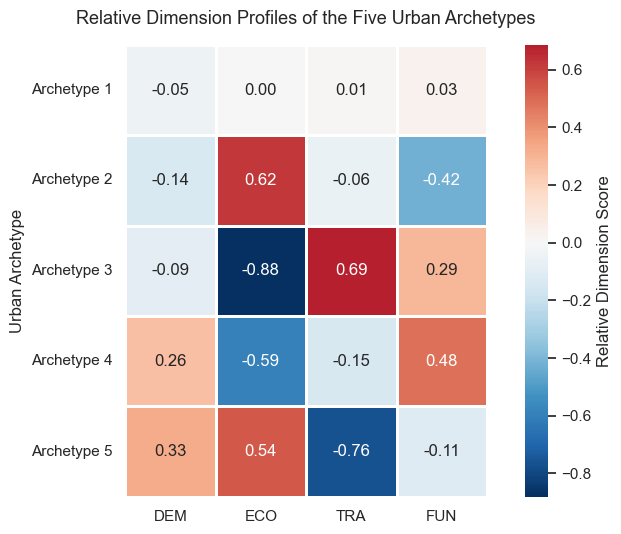

Figure saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Figure_5_1_Relative_Archetype_Profiles.png


In [73]:
# Final Relative Dimension Profiles of Urban Archetypes
heatmap_data = (
    archetype_summary
    .set_index("Archetype_Label")[
        [
            "Mean_DEM_Profile",
            "Mean_ECO_Profile",
            "Mean_TRA_Profile",
            "Mean_FUN_Profile",
        ]
    ]
)

# Short dimension labels for the figure
heatmap_data.columns = [
    "DEM",
    "ECO",
    "TRA",
    "FUN",
]

# Create figure
fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

sns.set_theme(style="white")

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Relative Dimension Score"
    },
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Urban Archetype")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
)

ax.set_title(
    "Relative Dimension Profiles of the Five Urban Archetypes",
    fontsize=13,
    pad=15,
)

fig.tight_layout()

# Save Figure
FIGURE_FILE = (
    OUTPUT_DIR
    / "Figure_5_1_Relative_Archetype_Profiles.png"
)

fig.savefig(
    FIGURE_FILE,
    dpi=600,
    bbox_inches="tight",
)

# Display only AFTER saving
plt.show()

print(f"Figure saved to: {FIGURE_FILE}")

In [74]:
#5 types
ARCHETYPE_NAMES = {
    1: "Balanced",
    2: "Economy-oriented",
    3: "Transport–Function-oriented",
    4: "Population–Function-oriented",
    5: "Population–Economy-oriented",
}

df["Archetype_Name"] = (
    df["Archetype_Ward"]
    .map(ARCHETYPE_NAMES)
)

In [75]:
# Final Urban Archetype Names
ARCHETYPE_NAMES = {
    1: "Balanced",
    2: "Economy-oriented",
    3: "Transport–Function-oriented",
    4: "Population–Function-oriented",
    5: "Population–Economy-oriented",
}

In [76]:
# Representative Cities Based on Ward Cluster Centres
representative_rows = []

for archetype in sorted(
    df["Archetype_Ward"].unique()
):
    # Select cities in the current archetype
    cluster_data = df[
        df["Archetype_Ward"] == archetype
    ].copy()

    # Calculate the mean relative profile of the archetype
    cluster_centre = (
        cluster_data[
            PROFILE_COLUMNS
        ]
        .mean()
        .to_numpy()
    )

    # Calculate each city's Euclidean distance
    # from the archetype centre
    city_profiles = (
        cluster_data[
            PROFILE_COLUMNS
        ]
        .to_numpy()
    )

    distances_to_centre = np.linalg.norm(
        city_profiles - cluster_centre,
        axis=1,
    )

    # Find the city closest to the cluster centre
    representative_position = (
        np.argmin(
            distances_to_centre
        )
    )

    representative_city = (
        cluster_data.iloc[
            representative_position
        ]
    )

    representative_rows.append({
        "Archetype":
            archetype,

        "Archetype_Name":
            ARCHETYPE_NAMES[
                archetype
            ],

        "ISO3":
            representative_city["ISO3"],

        "FUA_Code":
            representative_city["FUA_Code"],

        "FUA_Name":
            representative_city["FUA_Name"],

        "UHI":
            representative_city["UHI"],

        "Tier":
            representative_city["Tier_KMeans"],

        "DEM_profile":
            representative_city["DEM_profile"],

        "ECO_profile":
            representative_city["ECO_profile"],

        "TRA_profile":
            representative_city["TRA_profile"],

        "FUN_profile":
            representative_city["FUN_profile"],

        "Distance_to_Centre":
            distances_to_centre[
                representative_position
            ],
    })


representative_cities = (
    pd.DataFrame(
        representative_rows
    )
    .sort_values(
        "Archetype"
    )
    .reset_index(
        drop=True
    )
)
# Display Representative Cities
display(
    representative_cities.round(3)
)
# Save Representative Cities
REPRESENTATIVE_FILE = (
    OUTPUT_DIR
    / "Step_07_Archetype_Representative_Cities.xlsx"
)

representative_cities.to_excel(
    REPRESENTATIVE_FILE,
    index=False,
    engine="openpyxl",
)

print(
    f"Representative cities saved to: "
    f"{REPRESENTATIVE_FILE}"
)

,Archetype,Archetype_Name,ISO3,FUA_Code,FUA_Name,UHI,Tier,DEM_profile,ECO_profile,TRA_profile,FUN_profile,Distance_to_Centre
0,1,Balanced,GBR,UK013F,Newcastle upon Tyne,-1.098,4,0.117,-0.182,0.031,0.034,0.249
1,2,Economy-oriented,DEU,DE007F,Stuttgart,0.113,2,-0.287,0.664,-0.010,-0.367,0.167
2,3,Transport–Function-oriented,JPN,JPN03F,Nagoya,1.136,1,-0.040,-0.898,0.653,0.285,0.065
3,4,Population–Function-oriented,KOR,KOR04F,Gwangju,-0.804,4,0.113,-0.464,-0.165,0.516,0.196
4,5,Population–Economy-oriented,CAN,CAN06F,Edmonton,-1.009,4,0.248,0.571,-0.803,-0.016,0.133


Representative cities saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_07_Archetype_Representative_Cities.xlsx


In [77]:
#Tier × Archetype Cross-tabulation
tier_archetype_counts = pd.crosstab(
    df["Tier_KMeans"],
    df["Archetype_Name"],
)

tier_archetype_shares = pd.crosstab(
    df["Tier_KMeans"],
    df["Archetype_Name"],
    normalize="index",
).round(3)

# Display Results
print("Tier × Archetype (Counts)")
display(
    tier_archetype_counts
)

print()

print("Tier × Archetype (Row Percentages)")
display(
    tier_archetype_shares
)

# Save Results
COUNTS_FILE = (
    OUTPUT_DIR
    / "Step_07_Tier_Archetype_Counts.xlsx"
)

SHARES_FILE = (
    OUTPUT_DIR
    / "Step_07_Tier_Archetype_Shares.xlsx"
)

tier_archetype_counts.to_excel(
    COUNTS_FILE,
    engine="openpyxl",
)

tier_archetype_shares.to_excel(
    SHARES_FILE,
    engine="openpyxl",
)


print()
print(f"Counts table saved to:\n{COUNTS_FILE}")
print(f"Percentage table saved to:\n{SHARES_FILE}")

Tier × Archetype (Counts)


Archetype_Name,Balanced,Economy-oriented,Population–Economy-oriented,Population–Function-oriented,Transport–Function-oriented
Tier_KMeans,,,,,
1,4,2,2,1,3
2,6,6,1,1,2
3,5,2,0,2,4
4,5,4,3,3,0



Tier × Archetype (Row Percentages)


Archetype_Name,Balanced,Economy-oriented,Population–Economy-oriented,Population–Function-oriented,Transport–Function-oriented
Tier_KMeans,,,,,
1,0.333,0.167,0.167,0.083,0.250
2,0.375,0.375,0.062,0.062,0.125
3,0.385,0.154,0.000,0.154,0.308
4,0.333,0.267,0.200,0.200,0.000



Counts table saved to:
/Users/cc-hoa/Desktop/毕业论文代码/results/Step_07_Tier_Archetype_Counts.xlsx
Percentage table saved to:
/Users/cc-hoa/Desktop/毕业论文代码/results/Step_07_Tier_Archetype_Shares.xlsx


In [78]:
ORIGINAL_DIMENSIONS = [
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
]

PROFILE_COLUMNS = [
    "DEM_profile",
    "ECO_profile",
    "TRA_profile",
    "FUN_profile",
]

In [79]:
# Final Results
final_results = df[
    [
        "FUA_Code",
        "FUA_Name",
        "ISO3",
        "UHI",
        "UHI_rank",
        "Tier_KMeans",
        "Archetype_Ward",
        "Archetype_Name",
        *ORIGINAL_DIMENSIONS,
        *PROFILE_COLUMNS,
    ]
].sort_values(
    by=[
        "Archetype_Ward",
        "UHI",
    ],
    ascending=[
        True,
        False,
    ],
).reset_index(
    drop=True
)
display(
    final_results.round(3)
)
FINAL_RESULTS_FILE = (
    OUTPUT_DIR
    / "Step_07_Final_Archetypes.xlsx"
)

final_results.to_excel(
    FINAL_RESULTS_FILE,
    index=False,
    engine="openpyxl",
)

print(
    f"Final results saved to:\n{FINAL_RESULTS_FILE}"
)

,FUA_Code,FUA_Name,ISO3,UHI,UHI_rank,Tier_KMeans,Archetype_Ward,Archetype_Name,DEM_star,ECO_star,TRA_star,FUN_star,DEM_profile,ECO_profile,TRA_profile,FUN_profile
0,UK001F,London,GBR,1.529,4,1,1,Balanced,1.454,1.535,1.823,1.303,-0.074,0.006,0.294,-0.226
1,FR001F,Paris,FRA,1.524,5,1,1,Balanced,1.524,1.679,1.109,1.786,-0.000,0.154,-0.416,0.261
2,USA03F,Chicago,USA,1.073,10,1,1,Balanced,1.192,1.164,1.094,0.842,0.119,0.091,0.021,-0.231
3,USA06F,Philadelphia (Greater),USA,0.937,12,1,1,Balanced,0.817,0.938,1.167,0.826,-0.120,0.001,0.230,-0.111
4,USA07F,Dallas,USA,0.750,13,2,1,Balanced,1.015,0.978,0.363,0.646,0.264,0.228,-0.388,-0.105
5,DE001F,Berlin,DEU,0.330,17,2,1,Balanced,0.528,0.363,-0.270,0.701,0.197,0.032,-0.601,0.371
6,CAN02F,Montreal,CAN,0.169,19,2,1,Balanced,0.431,-0.022,0.262,0.004,0.262,-0.191,0.093,-0.165
7,DE006F,Ruhrgebiet,DEU,0.091,22,2,1,Balanced,-0.500,-0.010,0.331,0.544,-0.591,-0.101,0.240,0.452
8,FR002F,Lyon,FRA,-0.016,25,2,1,Balanced,-0.300,0.258,-0.104,0.082,-0.284,0.274,-0.088,0.098
9,UK008F,Manchester,GBR,-0.027,26,2,1,Balanced,0.133,-0.257,0.353,-0.335,0.160,-0.231,0.380,-0.309


Final results saved to:
/Users/cc-hoa/Desktop/毕业论文代码/results/Step_07_Final_Archetypes.xlsx


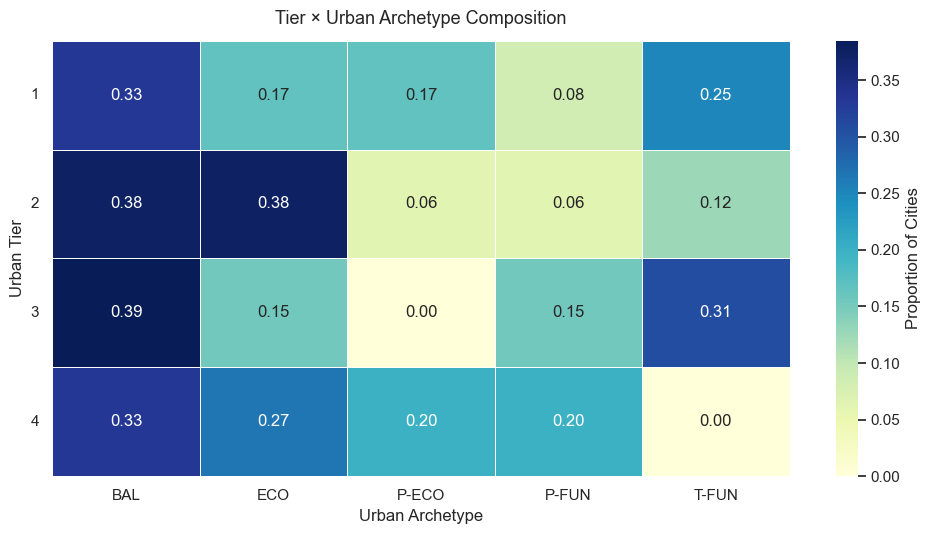

Figure saved to:
/Users/cc-hoa/Desktop/毕业论文代码/results/Figure_5_2_Tier_Archetype_Heatmap.png


In [80]:
#Tier × Archetype Heatmap
# Create a display copy with shortened archetype labels
heatmap_tier_archetype = (
    tier_archetype_shares.copy()
)

heatmap_tier_archetype.columns = [
    "BAL",
    "ECO",
    "P-ECO",
    "P-FUN",
    "T-FUN",
]


fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

sns.set_theme(style="white")

sns.heatmap(
    heatmap_tier_archetype,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Proportion of Cities"
    },
    ax=ax,
)

ax.set_title(
    "Tier × Urban Archetype Composition",
    fontsize=13,
    pad=12,
)

ax.set_xlabel(
    "Urban Archetype"
)

ax.set_ylabel(
    "Urban Tier"
)

plt.xticks(
    rotation=0
)

plt.yticks(
    rotation=0
)

fig.tight_layout()
# Save Figure
CROSS_HEATMAP_FILE = (
    OUTPUT_DIR
    / "Figure_5_2_Tier_Archetype_Heatmap.png"
)

fig.savefig(
    CROSS_HEATMAP_FILE,
    dpi=600,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to:\n{CROSS_HEATMAP_FILE}"
)

/var/folders/_j/0fcst3p15tv6k7pjkdz5jxbh0000gn/T/ipykernel_91494/1119724657.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotation_labels = heatmap_percent.applymap(


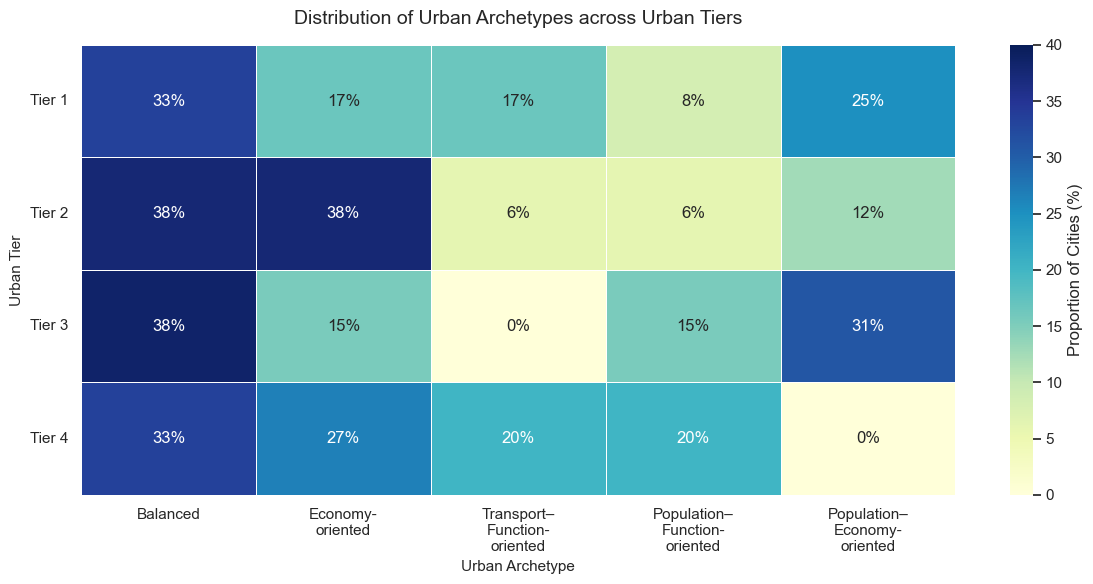

Figure saved to:
/Users/cc-hoa/Desktop/毕业论文代码/results/Figure_5_7_Tier_Archetype_Heatmap.png


In [82]:
#Figure 5.7 Tier × Urban Archetype Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Prepare data
heatmap_tier_archetype = tier_archetype_shares.copy()

# Final archetype names
heatmap_tier_archetype.columns = [
    "Balanced",
    "Economy-oriented",
    "Transport–Function-oriented",
    "Population–Function-oriented",
    "Population–Economy-oriented",
]

# Convert proportions into percentages
heatmap_percent = heatmap_tier_archetype * 100

# Percentage labels
annotation_labels = heatmap_percent.applymap(
    lambda x: f"{x:.0f}%"
)

#Draw heatmap
fig, ax = plt.subplots(
    figsize=(12, 6)
)

sns.heatmap(
    heatmap_percent,
    annot=annotation_labels,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Proportion of Cities (%)"
    },
    vmin=0,
    vmax=40,
    ax=ax,
)

# Labels
ax.set_title(
    "Distribution of Urban Archetypes across Urban Tiers",
    fontsize=14,
    pad=15,
)

ax.set_xlabel(
    "Urban Archetype",
    fontsize=11,
)

ax.set_ylabel(
    "Urban Tier",
    fontsize=11,
)

# Tier labels
ax.set_yticklabels(
    ["Tier 1", "Tier 2", "Tier 3", "Tier 4"],
    rotation=0,
)

# Archetype labels
ax.set_xticklabels(
    [
        "Balanced",
        "Economy-\noriented",
        "Transport–\nFunction-\noriented",
        "Population–\nFunction-\noriented",
        "Population–\nEconomy-\noriented",
    ],
    rotation=0,
    ha="center",
)

#Save figure
fig.tight_layout()

CROSS_HEATMAP_FILE = (
    OUTPUT_DIR
    / "Figure_5_7_Tier_Archetype_Heatmap.png"
)

fig.savefig(
    CROSS_HEATMAP_FILE,
    dpi=600,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Figure saved to:\n{CROSS_HEATMAP_FILE}"
)